In [1]:
import sys
!{sys.executable} -m pip install lightgbm

In [2]:
import re
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, precision_recall_curve, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Dict, List, Optional, Tuple

In [3]:
train_df = pd.read_csv("../../data/processed/combinedWithOdds.csv")
eval_df = pd.read_csv("../../data/evaluation/secondIterration/202425.csv")

In [4]:
print("Training shape:", train_df.shape)
print("Evaluation shape:", eval_df.shape)

columns_to_keep = [
    'Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
    'HTHG', 'HTAG', 'HTR', 'Attendance', 'Referee', 'HS', 'AS', 'HST', 'AST',
    'HHW', 'AHW', 'HC', 'AC', 'HF', 'AF', 'HFKC', 'AFKC', 'HO', 'AO', 'HY', 'AY',
    'HR', 'AR', '1XBH', '1XBD', '1XBA', 'B365H', 'B365D', 'B365A', 'B365>2.5', 'B365<2.5', 'B365AHH', 'B365AHA', 'B365AH',
    'BFH', 'BFD', 'BFA', 'BFEH', 'BFED', 'BFEA', 'BFDH', 'BFDD', 'BFDA',
    'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'VCH', 'VCD', 'VCA',
    'BSH', 'BSD', 'BSA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA',
    'GBH', 'GBD', 'GBA', 'GB>2.5', 'GB<2.5', 'GBAHH', 'GBAHA', 'GBAH',
    'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'LBAHH', 'LBAHA', 'LBAH',
    'PSH', 'PH', 'PSD', 'PD', 'PSA', 'PA', 'P>2.5', 'P<2.5', 'PAHH', 'PAHA',
    'SOH', 'SOD', 'SOA', 'SBH', 'SBD', 'SBA', 'SJH', 'SJD', 'SJA',
    'SYH', 'SYD', 'SYA', 'WHH', 'WHD', 'WHA',
    'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA',
    'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5',
    'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA',
    'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA',
    'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5',
    'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHh'
]

for df_ in [train_df, eval_df]:
    for col in columns_to_keep:
        if col not in df_.columns:
            df_[col] = 0
    df_ = df_[columns_to_keep]

train_df = train_df[columns_to_keep]
eval_df = eval_df[columns_to_keep]

def clean_and_engineer_features(
    df,
    columns_to_keep,
    all_teams=None,
    fit_teams=False,
    n_matches=5,
    drop_cols=['Time', 'Attendance', 'HHW', 'AHW', 'HO', 'AO', 'Div'],
):
    for col in columns_to_keep:
        if col not in df.columns:
            df[col] = np.nan
    df = df[columns_to_keep].copy()
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    def date_format_type(date_str):
        if not isinstance(date_str, str):
            return "not_a_string"
        patterns = {
            "%d/%m/%y": r"^\d{2}/\d{2}/\d{2}$",
            "%d/%m/%Y": r"^\d{2}/\d{2}/\d{4}$",
            "%Y-%m-%d": r"^\d{4}-\d{2}-\d{2}$",
            "%m-%d-%Y": r"^\d{2}-\d{2}-\d{4}$",
            "%Y/%m/%d": r"^\d{4}/\d{2}/\d{2}$",
        }
        for fmt, pat in patterns.items():
            if re.match(pat, date_str):
                return fmt
        return "unknown"
    df['DateFormat'] = df['Date'].apply(date_format_type)
    def parse_dates(row):
        date_str = row['Date']
        if isinstance(date_str, str):
            try:
                return pd.to_datetime(date_str, format='%d/%m/%y')
            except ValueError:
                try:
                    return pd.to_datetime(date_str, format='%d/%m/%Y')
                except ValueError:
                    return pd.NaT
        else:
            return pd.NaT
    df['Date'] = df.apply(parse_dates, axis=1)
    df = df.drop(columns=['DateFormat'], errors='ignore')
    df = df[df['Date'] >= pd.Timestamp('2000-08-18')]
    df = df.reset_index(drop=True)

    def get_season(date):
        if pd.isnull(date):
            return np.nan
        year = date.year
        month = date.month
        if month >= 8:
            return f"{year}-{str(year+1)[-2:]}"
        else:
            return f"{year-1}-{str(year)[-2:]}"
    newcols = {
        'Season': df['Date'].apply(get_season),
        'Year': df['Date'].dt.year,
        'Month': df['Date'].dt.month,
        'DayOfWeek': df['Date'].dt.dayofweek,
        'HomeWin': (df['FTR'] == 'H').astype(int),
    }
    df = pd.concat([df, pd.DataFrame(newcols, index=df.index)], axis=1)

    odds_cols = [
        'B365H', 'B365D', 'B365A', 'B365>2.5', 'B365<2.5', 'B365AHH', 'B365AHA', 'B365AH',
        'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'PSH', 'PSD', 'PSA', 'PH', 'PD', 'PA',
        'P>2.5', 'P<2.5', 'PAHH', 'PAHA', 'LBH', 'LBD', 'LBA', 'LBAHH', 'LBAHA', 'LBAH',
        'GBH', 'GBD', 'GBA', 'GB>2.5', 'GB<2.5', 'GBAHH', 'GBAHA', 'GBAH', 'BVH', 'BVD', 'BVA',
        'VCH', 'VCD', 'VCA', '1XBH', '1XBD', '1XBA', 'BWH', 'BWD', 'BWA', 'SOH', 'SOD', 'SOA',
        'SBH', 'SBD', 'SBA', 'CLH', 'CLD', 'CLA', 'BMGMH', 'BMGMD', 'BMGMA', 'BFDH', 'BFDD', 'BFDA',
        'BFH', 'BFD', 'BFA', 'BFEH', 'BFED', 'BFEA', 'SYH', 'SYD', 'SYA', 'SJH', 'SJD', 'SJA',
        'BSH', 'BSD', 'BSA', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU',
        'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH',
        'BbMxAHA', 'BbAvAHA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'Max>2.5', 'Max<2.5',
        'Avg>2.5', 'Avg<2.5', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'AHh'
    ]
    score_cols = [
        'FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST',
        'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR'
    ]
    for col in odds_cols + score_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.drop_duplicates()

    essential_odds = ['B365H', 'B365D', 'B365A', 'WHH', 'WHD', 'WHA', 'IWH', 'IWD', 'IWA']
    core_odds = odds_cols
    essentials = [col for col in essential_odds if col in df.columns]
    df = df.dropna(subset=essentials).reset_index(drop=True)
    for col in core_odds:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mean())
    df = df.sort_values('Date')
    roll_features = {
        'HomeTeam_mean_FTHG': df.groupby('HomeTeam')['FTHG'].transform(lambda x: x.shift(1).expanding().mean()),
        'AwayTeam_mean_FTAG': df.groupby('AwayTeam')['FTAG'].transform(lambda x: x.shift(1).expanding().mean()),
        'HomeTeam_str': df['HomeTeam'],
        'AwayTeam_str': df['AwayTeam'],
    }
    df = pd.concat([df, pd.DataFrame(roll_features, index=df.index)], axis=1)

    if fit_teams:
        unique_teams = sorted(set(df['HomeTeam_str']).union(set(df['AwayTeam_str'])))
    else:
        unique_teams = all_teams

    team_onehot = {}
    for team in unique_teams:
        team_onehot[f"HomeTeam_{team}"] = (df['HomeTeam_str'] == team).astype(int)
        team_onehot[f"AwayTeam_{team}"] = (df['AwayTeam_str'] == team).astype(int)
    df = pd.concat([df, pd.DataFrame(team_onehot, index=df.index)], axis=1)
    df = df.drop(columns=['HomeTeam', 'AwayTeam'], errors='ignore')
    df = df.rename(columns={'HomeTeam_str': 'HomeTeam', 'AwayTeam_str': 'AwayTeam'})

    def add_recent_form_features(df, n_matches=5):
        base = df.copy()
        base = base.sort_values('Date')
        home_df = base[['Date', 'HomeTeam', 'FTHG', 'FTAG']].rename(
            columns={'HomeTeam': 'Team', 'FTHG': 'GoalsFor', 'FTAG': 'GoalsAgainst'})
        away_df = base[['Date', 'AwayTeam', 'FTAG', 'FTHG']].rename(
            columns={'AwayTeam': 'Team', 'FTAG': 'GoalsFor', 'FTHG': 'GoalsAgainst'})
        results = pd.concat([home_df, away_df], ignore_index=True)
        results = results.sort_values(['Team', 'Date'])
        def get_points(row):
            return 3 if row['GoalsFor'] > row['GoalsAgainst'] else (1 if row['GoalsFor'] == row['GoalsAgainst'] else 0)
        results['Points'] = results.apply(get_points, axis=1)
        results['RollingGF'] = results.groupby('Team')['GoalsFor'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).mean())
        results['RollingGA'] = results.groupby('Team')['GoalsAgainst'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).mean())
        results['RollingPoints'] = results.groupby('Team')['Points'].transform(lambda x: x.shift(1).rolling(n_matches, min_periods=1).sum())
        def get_form(row, team_col):
            team = row[team_col]
            date = row['Date']
            row_form = results[(results['Team'] == team) & (results['Date'] < date)].sort_values('Date').tail(1)
            if row_form.empty:
                return pd.Series([np.nan, np.nan, np.nan])
            return row_form[['RollingGF', 'RollingGA', 'RollingPoints']].values[0]
        base[['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts']] = base.apply(
            lambda row: get_form(row, 'HomeTeam'), axis=1, result_type='expand')
        base[['AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']] = base.apply(
            lambda row: get_form(row, 'AwayTeam'), axis=1, result_type='expand')
        return base
    df = add_recent_form_features(df, n_matches=n_matches)
    df = df.dropna(subset=['HomeRecentGF', 'AwayRecentGF'])

    df = df.replace([np.inf, -np.inf], np.nan)
    for col in df.select_dtypes(include=['number']):
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include=['object', 'category']):
        df[col] = df[col].fillna(df[col].mode()[0])
    df = df.drop_duplicates().reset_index(drop=True)

    threshold = 0.95
    df = df.loc[:, df.isnull().mean() < threshold]
    df = df.copy()
    return df, unique_teams if fit_teams else all_teams

train_df_clean, all_teams = clean_and_engineer_features(train_df, columns_to_keep, fit_teams=True)
eval_df_clean, _ = clean_and_engineer_features(eval_df, columns_to_keep, all_teams=all_teams)

Training shape: (12931, 127)
Evaluation shape: (380, 120)


/Users/bashaardhoot/miniforge3/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/bashaardhoot/miniforge3/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/bashaardhoot/miniforge3/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/bashaardhoot/miniforge3/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/bashaardhoot/miniforge3/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/bashaardhoot/miniforge3/lib/python3.10

In [5]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',
    'HC', 'AC',
    'HF', 'AF',
    'HY', 'AY',
    'HR', 'AR',
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts',
    'BTTS', 'Away_2plus', 'Home_2plus',
    'target_home_plus_two', 'target_away_plus_two',
    'HomeWin'
]


=== Evaluating HomeWin (XGBoost & LightGBM only) ===
Dropping problematic columns: ['B365_2.5', 'B365_2.5', 'GB_2.5', 'GB_2.5', 'P_2.5', 'P_2.5', 'BbMx_2.5', 'BbAv_2.5', 'BbMx_2.5', 'BbAv_2.5', 'Max_2.5', 'Max_2.5', 'Avg_2.5', 'Avg_2.5']

=== Algorithm Comparison ===
XGBoost: Accuracy=0.6515, F1=0.6073
              precision    recall  f1-score   support

           0       0.66      0.71      0.69       846
           1       0.64      0.58      0.61       735

    accuracy                           0.65      1581
   macro avg       0.65      0.65      0.65      1581
weighted avg       0.65      0.65      0.65      1581


Top 20 Feature Importances (XGBoost):
IWA                       0.066864
WHH                       0.023052
B365H                     0.018082
AwayTeam_Swansea          0.011672
B365A                     0.011655
AwayTeam_Middlesbrough    0.010846
HomeTeam_Fulham           0.010655
HomeTeam_Brighton         0.010554
AwayTeam_West Brom        0.009902
HomeTeam_Man C

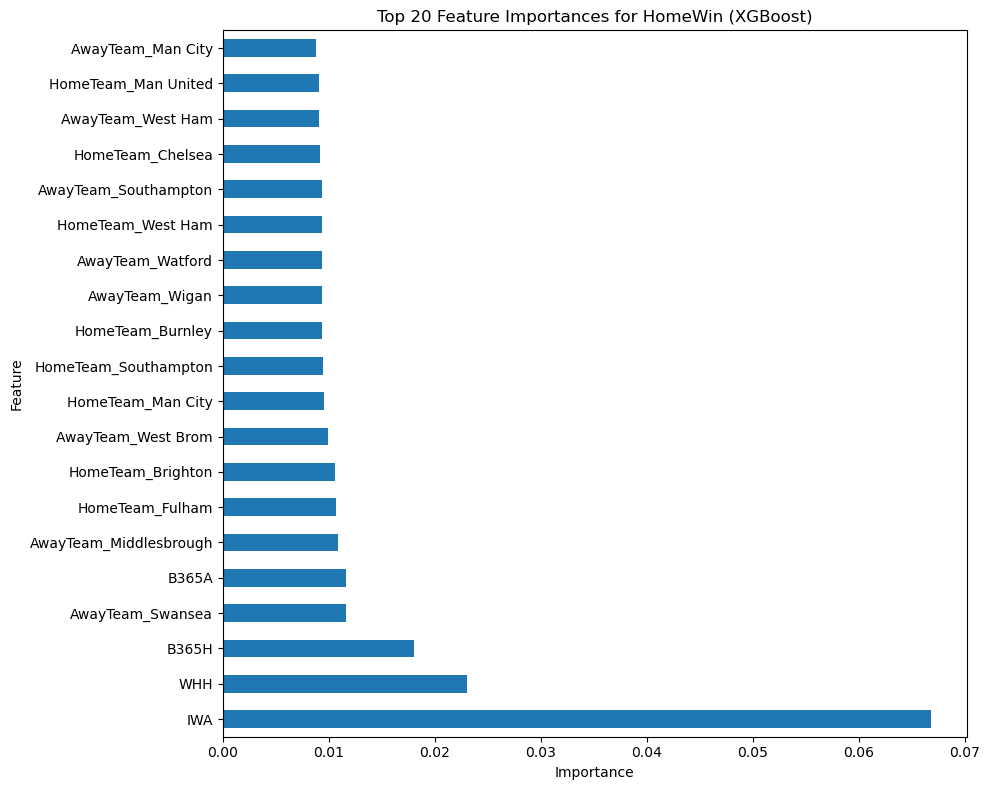


Best accuracy for XGBoost: 0.6515 at threshold: 0.50


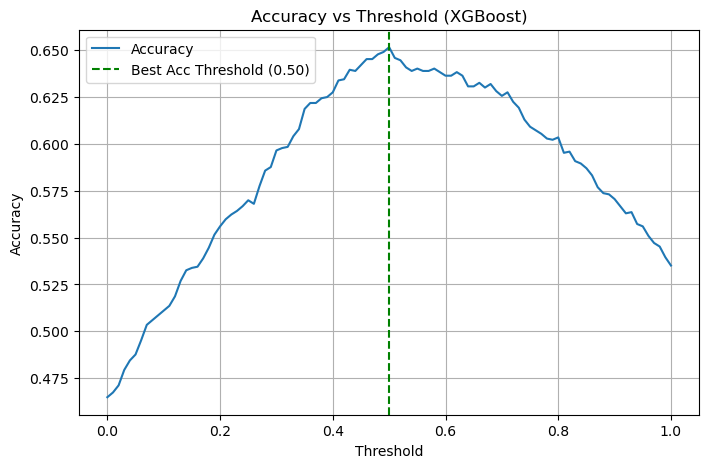


Best threshold for F1 (XGBoost): 0.204
F1-score at best threshold: 0.651
Precision at best threshold: 0.516
Recall at best threshold: 0.882

Classification report (best F1 threshold) (XGBoost):
              precision    recall  f1-score   support

           0       0.73      0.28      0.41       846
           1       0.52      0.88      0.65       735

    accuracy                           0.56      1581
   macro avg       0.62      0.58      0.53      1581
weighted avg       0.63      0.56      0.52      1581



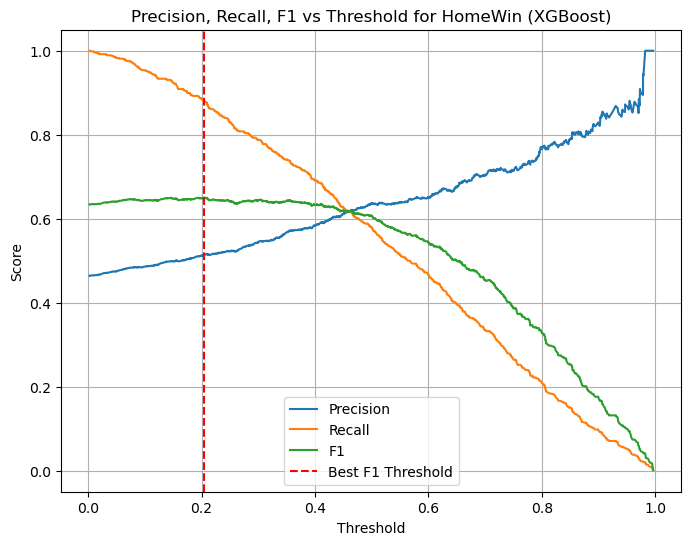

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2899, number of negative: 3421
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004810 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8837
[LightGBM] [Info] Number of data points in the train set: 6320, number of used features: 163
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458703 -> initscore=-0.165567
[LightGBM] [Info] Start training from score -0.165567
LightGBM: Accuracy=0.6578, F1=0.6138
              precision    recall  f1-score   support

           0       0.67      0.72      0.69       846
           1       0.65      0.59      0.61       735

    accuracy                           0.66      1581
   macro avg       0.66      0.65      0.65      1581
weighted avg       0.66      0.66      0.66      1581



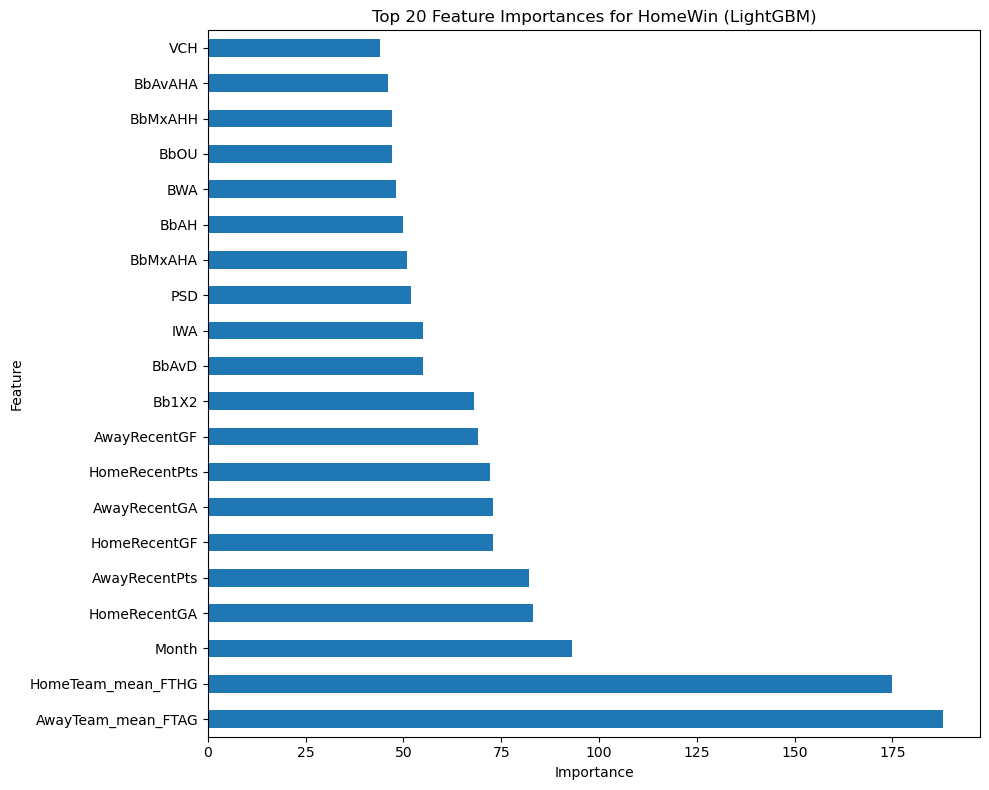


Best accuracy for LightGBM: 0.6578 at threshold: 0.49


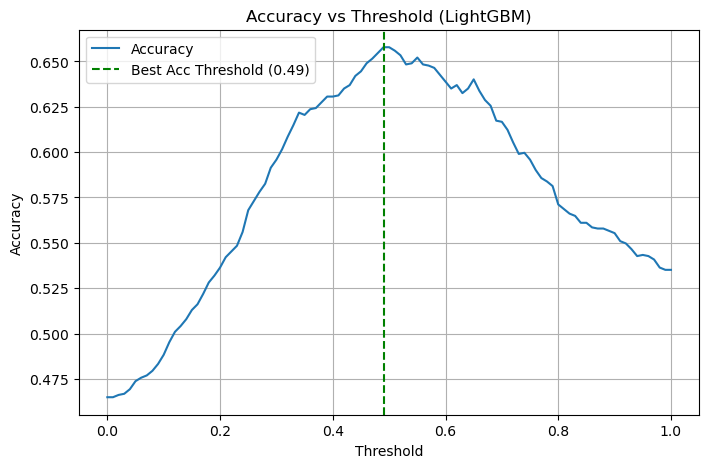


Best threshold for F1 (LightGBM): 0.327
F1-score at best threshold: 0.667
Precision at best threshold: 0.558
Recall at best threshold: 0.830

Classification report (best F1 threshold) (LightGBM):
              precision    recall  f1-score   support

           0       0.74      0.43      0.54       846
           1       0.56      0.83      0.67       735

    accuracy                           0.62      1581
   macro avg       0.65      0.63      0.61      1581
weighted avg       0.66      0.62      0.60      1581



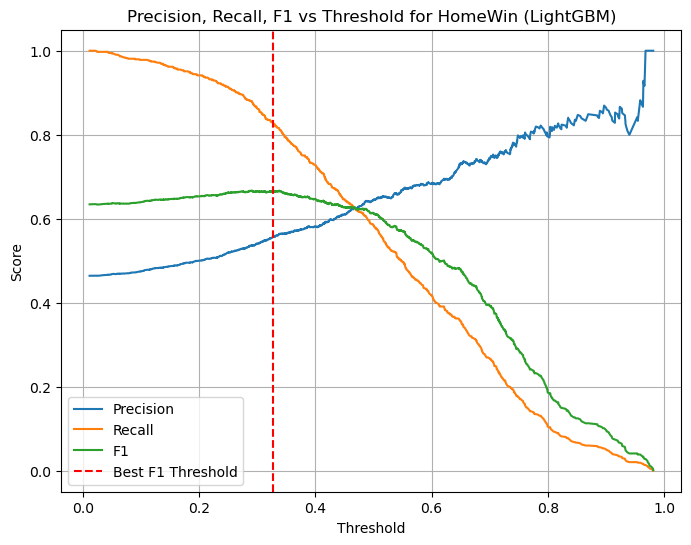

In [6]:
def train_homewin_boosted(df, cols_to_drop, top_n=20):
    import re
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from sklearn.metrics import classification_report, precision_recall_curve, accuracy_score, f1_score
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    target_col = 'HomeWin'
    print(f"\n=== Evaluating {target_col} (XGBoost & LightGBM only) ===")
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df[target_col]

    def safe_xgb_colnames(df):
        df = df.copy()
        df.columns = [re.sub(r'[\[\]<>]', '_', c) for c in df.columns]
        return df

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train_xgb = safe_xgb_colnames(X_train)
    X_test_xgb = safe_xgb_colnames(X_test)

    X_train_xgb = X_train_xgb.apply(pd.to_numeric, errors='coerce').fillna(0)
    X_test_xgb = X_test_xgb.apply(pd.to_numeric, errors='coerce').fillna(0)

    bad_columns = []
    for col in X_train_xgb.columns:
        first_val = X_train_xgb[col].iloc[0]
        if isinstance(first_val, (pd.Series, pd.DataFrame)) or not np.isscalar(first_val):
            bad_columns.append(col)
    if bad_columns:
        print("Dropping problematic columns:", bad_columns)
        X_train_xgb = X_train_xgb.drop(columns=bad_columns)
        X_test_xgb = X_test_xgb.drop(columns=bad_columns)

    X_train_xgb = X_train_xgb.select_dtypes(include=[np.number])
    X_test_xgb = X_test_xgb.select_dtypes(include=[np.number])
    X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

    algorithms = {
        "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
        "LightGBM": LGBMClassifier(random_state=42),
    }

    print("\n=== Algorithm Comparison ===")
    results = {}
    for name, clf in algorithms.items():
        clf.fit(X_train_xgb, y_train)
        y_pred = clf.predict(X_test_xgb)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}")
        print(classification_report(y_test, y_pred))

        if name == "XGBoost":
            importances = clf.feature_importances_
        else:
            importances = clf.feature_importances_

        feat_importances = pd.Series(importances, index=X_train_xgb.columns)
        top_feats = feat_importances.sort_values(ascending=False).head(top_n)
        print(f"\nTop {top_n} Feature Importances ({name}):")
        print(top_feats.to_string())

        plt.figure(figsize=(10, 8))
        top_feats.plot(kind='barh')
        plt.title(f'Top {top_n} Feature Importances for {target_col} ({name})')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

        results[name] = {
            'model': clf,
            'feature_importances': feat_importances,
            'top_feats': top_feats,
            'y_pred': y_pred,
            'accuracy': acc,
            'f1': f1,
        }

        if hasattr(clf, "predict_proba"):
            y_probs = clf.predict_proba(X_test_xgb)[:, 1]
            thresholds = np.linspace(0, 1, 101)
            accuracies = []
            best_acc = 0
            best_acc_thresh = 0.5

            for t in thresholds:
                y_pred_acc = (y_probs >= t).astype(int)
                acc_t = accuracy_score(y_test, y_pred_acc)
                accuracies.append(acc_t)
                if acc_t > best_acc:
                    best_acc = acc_t
                    best_acc_thresh = t

            print(f"\nBest accuracy for {name}: {best_acc:.4f} at threshold: {best_acc_thresh:.2f}")

            plt.figure(figsize=(8,5))
            plt.plot(thresholds, accuracies, label='Accuracy')
            plt.axvline(best_acc_thresh, color='g', linestyle='--', label=f'Best Acc Threshold ({best_acc_thresh:.2f})')
            plt.xlabel('Threshold')
            plt.ylabel('Accuracy')
            plt.title(f'Accuracy vs Threshold ({name})')
            plt.legend()
            plt.grid()
            plt.show()

            precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs)
            f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
            best_idx = np.argmax(f1_scores[:-1])
            best_threshold = thresholds_pr[best_idx]
            print(f"\nBest threshold for F1 ({name}): {best_threshold:.3f}")
            print(f"F1-score at best threshold: {f1_scores[best_idx]:.3f}")
            print(f"Precision at best threshold: {precision[best_idx]:.3f}")
            print(f"Recall at best threshold: {recall[best_idx]:.3f}")

            y_pred_best = (y_probs >= best_threshold).astype(int)
            print(f"\nClassification report (best F1 threshold) ({name}):")
            print(classification_report(y_test, y_pred_best))

            plt.figure(figsize=(8,6))
            plt.plot(thresholds_pr, precision[:-1], label='Precision')
            plt.plot(thresholds_pr, recall[:-1], label='Recall')
            plt.plot(thresholds_pr, f1_scores[:-1], label='F1')
            plt.axvline(best_threshold, color='r', linestyle='--', label='Best F1 Threshold')
            plt.xlabel('Threshold')
            plt.ylabel('Score')
            plt.title(f'Precision, Recall, F1 vs Threshold for {target_col} ({name})')
            plt.legend()
            plt.grid()
            plt.show()

    return results, X_test_xgb, y_test

results, X_test_xgb, y_test_xgb = train_homewin_boosted(train_df_clean, cols_to_drop, top_n=20)